# seaaroundus Python API demo

This notebook demonstrates the Python implementation of the `seaaroundus` package (mirroring the R [`rseaaroundus`](https://github.com/robsalasco/rseaaroundus) package):
1. [Region lookup](#1-discover-regions)
2. [Catch time series](#2-catch-time-series)
3. [Local caching of API responses](#3-response-caching) (avoids antisocial repeated API calls)
4. [Cache management](#4-cache-management)
5. [Batch downloads for multiple countries](#5-batch-download-for-several-countries)
6. [Historic endpoints](#6-historic-endpoints)
7. [Optional charts](#7-optional-charts)

**Data use:** Sea Around Us reconstructed catch data are licensed under [CC BY-NC-SA 4.0](https://creativecommons.org/licenses/by-nc-sa/4.0/) for non-commercial use. See `DATA_USE` in the repo root and the [citation policy](http://www.seaaroundus.org/citation-policy/).

In [ ]:
# imports and display set-up
from pathlib import Path
import pandas as pd
import seaaroundus as sau

# Project-local cache for this demo (easy to inspect/delete).
# Default without this would be ~/.cache/seaaroundus
CACHE_DIR = Path("../.cache/seaaroundus-demo").resolve()
client = sau.configure_client(cache=CACHE_DIR, request_source="seaaroundus-demo")

print("Package version:", sau.__version__)
print("Cache directory:", CACHE_DIR)
print("Default cache dir:", sau.default_cache_dir())

## 1. Discover regions

Use `list_regions` to browse available EEZs. `find_region` ranks titles with fuzzy matching – e.g. `"Brazil"` → `"Brazil (mainland)"` – and `search_regions` shows all candidates with scores.

In [ ]:
# TODO: enable better fuzzy matching for region names
eezs = sau.list_regions("eez", client=client)
print(f"{len(eezs)} EEZ{'' if len(eezs) == 1 else 's'} available")
eezs.head(10)

In [ ]:
# Ranked lookup: e.g. "Brazil" resolves to "Brazil (mainland)" over other Brazilian EEZs.

region_name = "Tanzania"
brazil = sau.find_region("eez", region_name, client=client, verbose=True)
if brazil is None:
    display(sau.search_regions("eez", region_name, client=client))
    raise ValueError(
        f"Could not confidently match {region_name} – inspect candidates above"
    )

nation_id = int(brazil["id"])
print(f"\nUsing EEZ id {nation_id}: {brazil['title']}")

## 2. Catch time series

- `catch_data` → wide table (years as index, categories as columns) – like the R `catchdata()` function
- `catch_data_long` → tidy long format – usually better for plotting/modelling

Reconstructed catch currently runs through **2019**.

In [ ]:
catch_wide = sau.catch_data("eez", nation_id, limit=5, client=client)
print("Shape:", catch_wide.shape)
catch_wide.tail()

In [ ]:
catch_long = sau.catch_data_long(
    "eez",
    nation_id,
    measure="value",
    dimension="functionalgroup",
    limit=8,
    client=client,
)
catch_long.query("year >= 2010").head(12)

In [ ]:
recent = catch_long[catch_long["year"] >= 2010].copy()
top_groups = (
    recent.groupby("category", as_index=False)["value"]
    .sum()
    .sort_values("value", ascending=False)
    .head(8)
)
top_groups

## 3. Response caching

Every GET/POST response is stored on disk. Re-running the same query reads from cache instead of hitting the network.

- `refresh=True` on any call bypasses cache for that request
- `client.cache_stats` shows hit/miss counts
- Batch downloads skip the inter-request sleep when serving from cache

In [ ]:
import time

# Reset stats for a clean demo (optional)
client.cache.stats.hits = 0
client.cache.stats.misses = 0

start = time.perf_counter()
_ = sau.catch_data("eez", nation_id, limit=5, client=client)
first_elapsed = time.perf_counter() - start
first_cached = client.last_request_cached

start = time.perf_counter()
_ = sau.catch_data("eez", nation_id, limit=5, client=client)
second_elapsed = time.perf_counter() - start
second_cached = client.last_request_cached

print(f"First call:  cached={first_cached},  {first_elapsed:.3f}s")
print(f"Second call: cached={second_cached}, {second_elapsed:.3f}s")
print(f"Cache stats: {client.cache_stats}")

In [8]:
fresh = sau.catch_data("eez", nation_id, limit=5, client=client, refresh=True)
print("Fetched fresh data; last request cached:", client.last_request_cached)
fresh.tail(3)

Fetched fresh data; last request cached: False


category,"Emperors, scavengers","Jacks, pompanos","Mackerels, tunas, bonitos",Others,Sardinellas,"Sharks, rays, skates"
year,,,,,,
2017,6023.154,4665.422,6813.100,99129.88,3602.100,10447.000
2018,6140.612,4630.499,11517.350,101683.23,10174.400,7223.693
2019,4680.727,4023.865,3194.732,101768.34,8543.229,7304.338


## 4. Cache management

| Action | Code |
|--------|------|
| Clear default cache | `sau.clear_cache()` |
| Clear this client's cache | `client.clear_cache()` |
| Bypass cache once | `sau.catch_data(..., refresh=True)` |
| Custom cache location | `sau.configure_client(cache=Path("./my-cache"))` |
| Disable globally | set env var `SEAAROUNDUS_CACHE_DISABLE=1` |
| Custom location globally | set env var `SEAAROUNDUS_CACHE_DIR=/path/to/cache` |

In [9]:
cache_files = sorted(CACHE_DIR.rglob("*.json"))
print(
    f"{len(cache_files)} cached response{'' if len(cache_files) == 1 else 's'} on disk"
)
for path in cache_files[:5]:
    print(" ", path.relative_to(CACHE_DIR))
if len(cache_files) > 5:
    print(f"  … and {len(cache_files) - 5} more")

348 cached responses on disk
  00/00ace5e6172605a99badfc6423c07f873846bc18bdd2ae2d0703c604c72becf0.json
  01/01b499b9eb9bf1509852075130a4ce51aa865445d355c86da52ead2e770af4ed.json
  01/01e4d8f2a896f7d4ee1550c896d46f041ba03be21ec64ea36934c76fcae101b6.json
  02/02b545815b0f81306b1ddcc29d778a48ad2994cbfdf1e30d38864abae8217718.json
  02/02c27bcd8f63dc28b5a1f22fc045cc1a10cdc534f01eb22835e5f392dfbcd4b1.json
  … and 343 more


## 5. Batch download for multiple countries

Batch helpers:
1. Match your country names → SAU fishing-entity IDs
2. Download time series for each country
3. Reuse the cache on repeat runs

In [10]:
countries = pd.DataFrame(
    {
        "iso_a3": ["BRA", "IDN", "PHL"],
        "country": ["Brazil", "Indonesia", "Philippines"],
    }
)

matched = sau.match_countries_to_fishing_entities(countries, client=client)
matched

,country,fishing_entity_id,sau_country,iso_a3
0,Brazil,15,Brazil,BRA
1,Indonesia,83,Indonesia,IDN
2,Philippines,138,Philippines,PHL


In [11]:
totals = sau.download_country_fisheries_timeseries(
    countries,
    years=10,
    measure="value",
    client=client,
    show_progress=True,
)

pivot = totals.pivot(index="year", columns="country", values="value")
pivot.tail()

country,Brazil,Indonesia,Philippines
year,,,
2015,1.260231e+09,6.058450e+09,2.955232e+09
2016,1.494616e+09,7.000187e+09,2.914408e+09
2017,1.709071e+09,1.143425e+10,2.655086e+09
2018,1.110828e+09,6.349173e+09,2.235752e+09
2019,1.143239e+09,7.421395e+09,2.388512e+09


In [12]:
start = time.perf_counter()
cached_totals = sau.download_country_fisheries_timeseries(
    countries,
    years=10,
    measure="value",
    client=client,
)
elapsed = time.perf_counter() - start

print(f"Cached batch elapsed: {elapsed:.3f}s")
print(f"Same result: {cached_totals.equals(totals)}")
print(client.cache_stats)

Cached batch elapsed: 0.008s
Same result: True
CacheStats(hits=11, misses=0, writes=1)


In [13]:
breakdown = sau.download_country_fisheries_breakdown(
    countries,
    dimension="functionalgroup",
    measure="value",
    years=10,
    limit=10,
    client=client,
)

breakdown.groupby(["country", "category"])["value"].sum().sort_values(
    ascending=False
).head(15)

country      category                            
Indonesia    Medium demersals (30 - 89 cm)           1.167895e+10
             Shrimps                                 9.978714e+09
             Medium pelagics (30 - 89 cm)            9.119464e+09
             Large pelagics (>=90 cm)                8.925215e+09
             Others                                  6.911630e+09
             Medium reef assoc. fish (30 - 89 cm)    6.618034e+09
Philippines  Medium demersals (30 - 89 cm)           6.591180e+09
Indonesia    Small pelagics (<30 cm)                 6.088579e+09
Brazil       Medium demersals (30 - 89 cm)           6.060244e+09
Indonesia    Large demersals (>=90 cm)               6.047672e+09
Philippines  Medium pelagics (30 - 89 cm)            5.597112e+09
             Large pelagics (>=90 cm)                5.139592e+09
Indonesia    Medium benthopelagics (30 - 89 cm)      2.445389e+09
Brazil       Shrimps                                 2.421121e+09
Philippines  Other demersa

## 6. Historic endpoints

These mirror the R package. Some endpoints may be unavailable or slow depending on SAU server status – the cells below handle failures gracefully.

In [14]:
entities = sau.list_fishing_entities(client=client)
print(f"{len(entities)} fishing entities")
entities.query("sau_country.str.contains('Brazil', case=False)", engine="python")

217 fishing entities


,country_id,sau_country,fishing_entity_id,norm_name
22,76.0,Brazil,15,brazil


In [15]:
try:
    mti = sau.marine_trophic_index("eez", nation_id, client=client)
    display(mti.tail())
except Exception as exc:
    print("MTI endpoint unavailable or errored:", exc)

/var/folders/tp/x_9dbyf149d6kw_k79l_kk4m0000gq/T/ipykernel_70210/4151565885.py:2: DeprecationWarning: marine_trophic_index is deprecated: the upstream Sea Around Us marine-trophic-index endpoint currently returns HTTP 500.
  mti = sau.marine_trophic_index("eez", nation_id, client=client)


MTI endpoint unavailable or errored: Sea Around Us API request failed for http://api.seaaroundus.org/api/v1/eez/marine-trophic-index/?region_id=834&transfer_efficiency=0.1


In [16]:
try:
    split = sau.eez_vs_high_seas(client=client)
    display(split.tail())
except Exception as exc:
    print("EEZ vs high-seas endpoint unavailable or errored:", exc)

EEZ vs high-seas endpoint unavailable or errored: 'list' object has no attribute 'get'


/var/folders/tp/x_9dbyf149d6kw_k79l_kk4m0000gq/T/ipykernel_70210/3759187144.py:2: DeprecationWarning: eez_vs_high_seas is deprecated: the upstream Sea Around Us global/eez-vs-high-seas endpoint is currently unavailable/timing out.
  split = sau.eez_vs_high_seas(client=client)


## 7. Optional charts

Requires: `pip install -e ".[plot]"`

The examples below show several plot variants (taxon, sector, reporting status, MTI, and global EEZ vs. high seas). Plot titles now include the matched nation name.

In [17]:
%load_ext autoreload
%autoreload 2


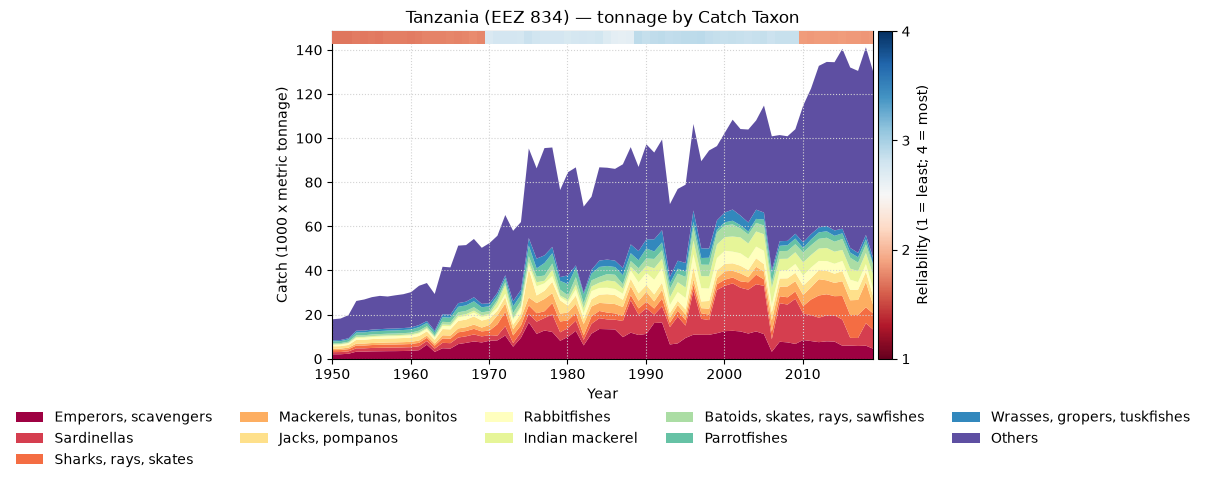

In [ ]:
# Taxon breakdown
try:
    fig, ax = sau.plot_catch_data(
        "eez",
        nation_id,
        dimension="taxon",
        measure="tonnage",
        limit=10,
        figsize=(10, 5),
    )
    fig
except ImportError as exc:
    print("Install plot extras:", exc)

In [ ]:
# Taxon breakdown – with uncerainty
try:
    fig, ax = sau.plot_catch_data(
        "eez",
        nation_id,
        dimension="taxon",
        measure="tonnage",
        limit=10,
        figsize=(10, 5),
    )
    fig
except ImportError as exc:
    print("Install plot extras:", exc)


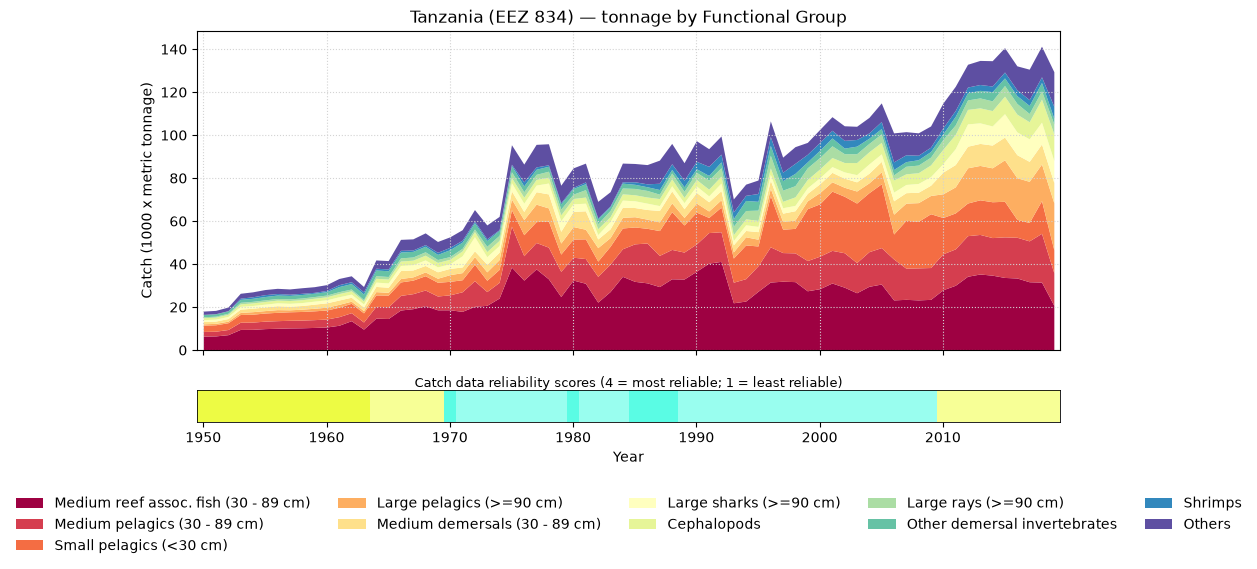

In [19]:
# Functional group breakdown
try:
    fig, ax = sau.plot_catch_data(
        "eez",
        nation_id,
        dimension="functionalgroup",
        measure="tonnage",
        limit=10,
    )
    fig
except ImportError as exc:
    print("Install plot extras:", exc)

In [20]:
from __future__ import annotations

import warnings
from typing import TYPE_CHECKING

import pandas as pd

from seaaroundus.catch import catch_data_long
from seaaroundus.client import SeaAroundUsClient, get_client
from seaaroundus.global_data import eez_vs_high_seas
from seaaroundus.mti import marine_trophic_index
from seaaroundus.regions import list_regions
from seaaroundus.types import Dimension, Measure, MTIType, Region

if TYPE_CHECKING:
    from matplotlib.axes import Axes
    from matplotlib.figure import Figure


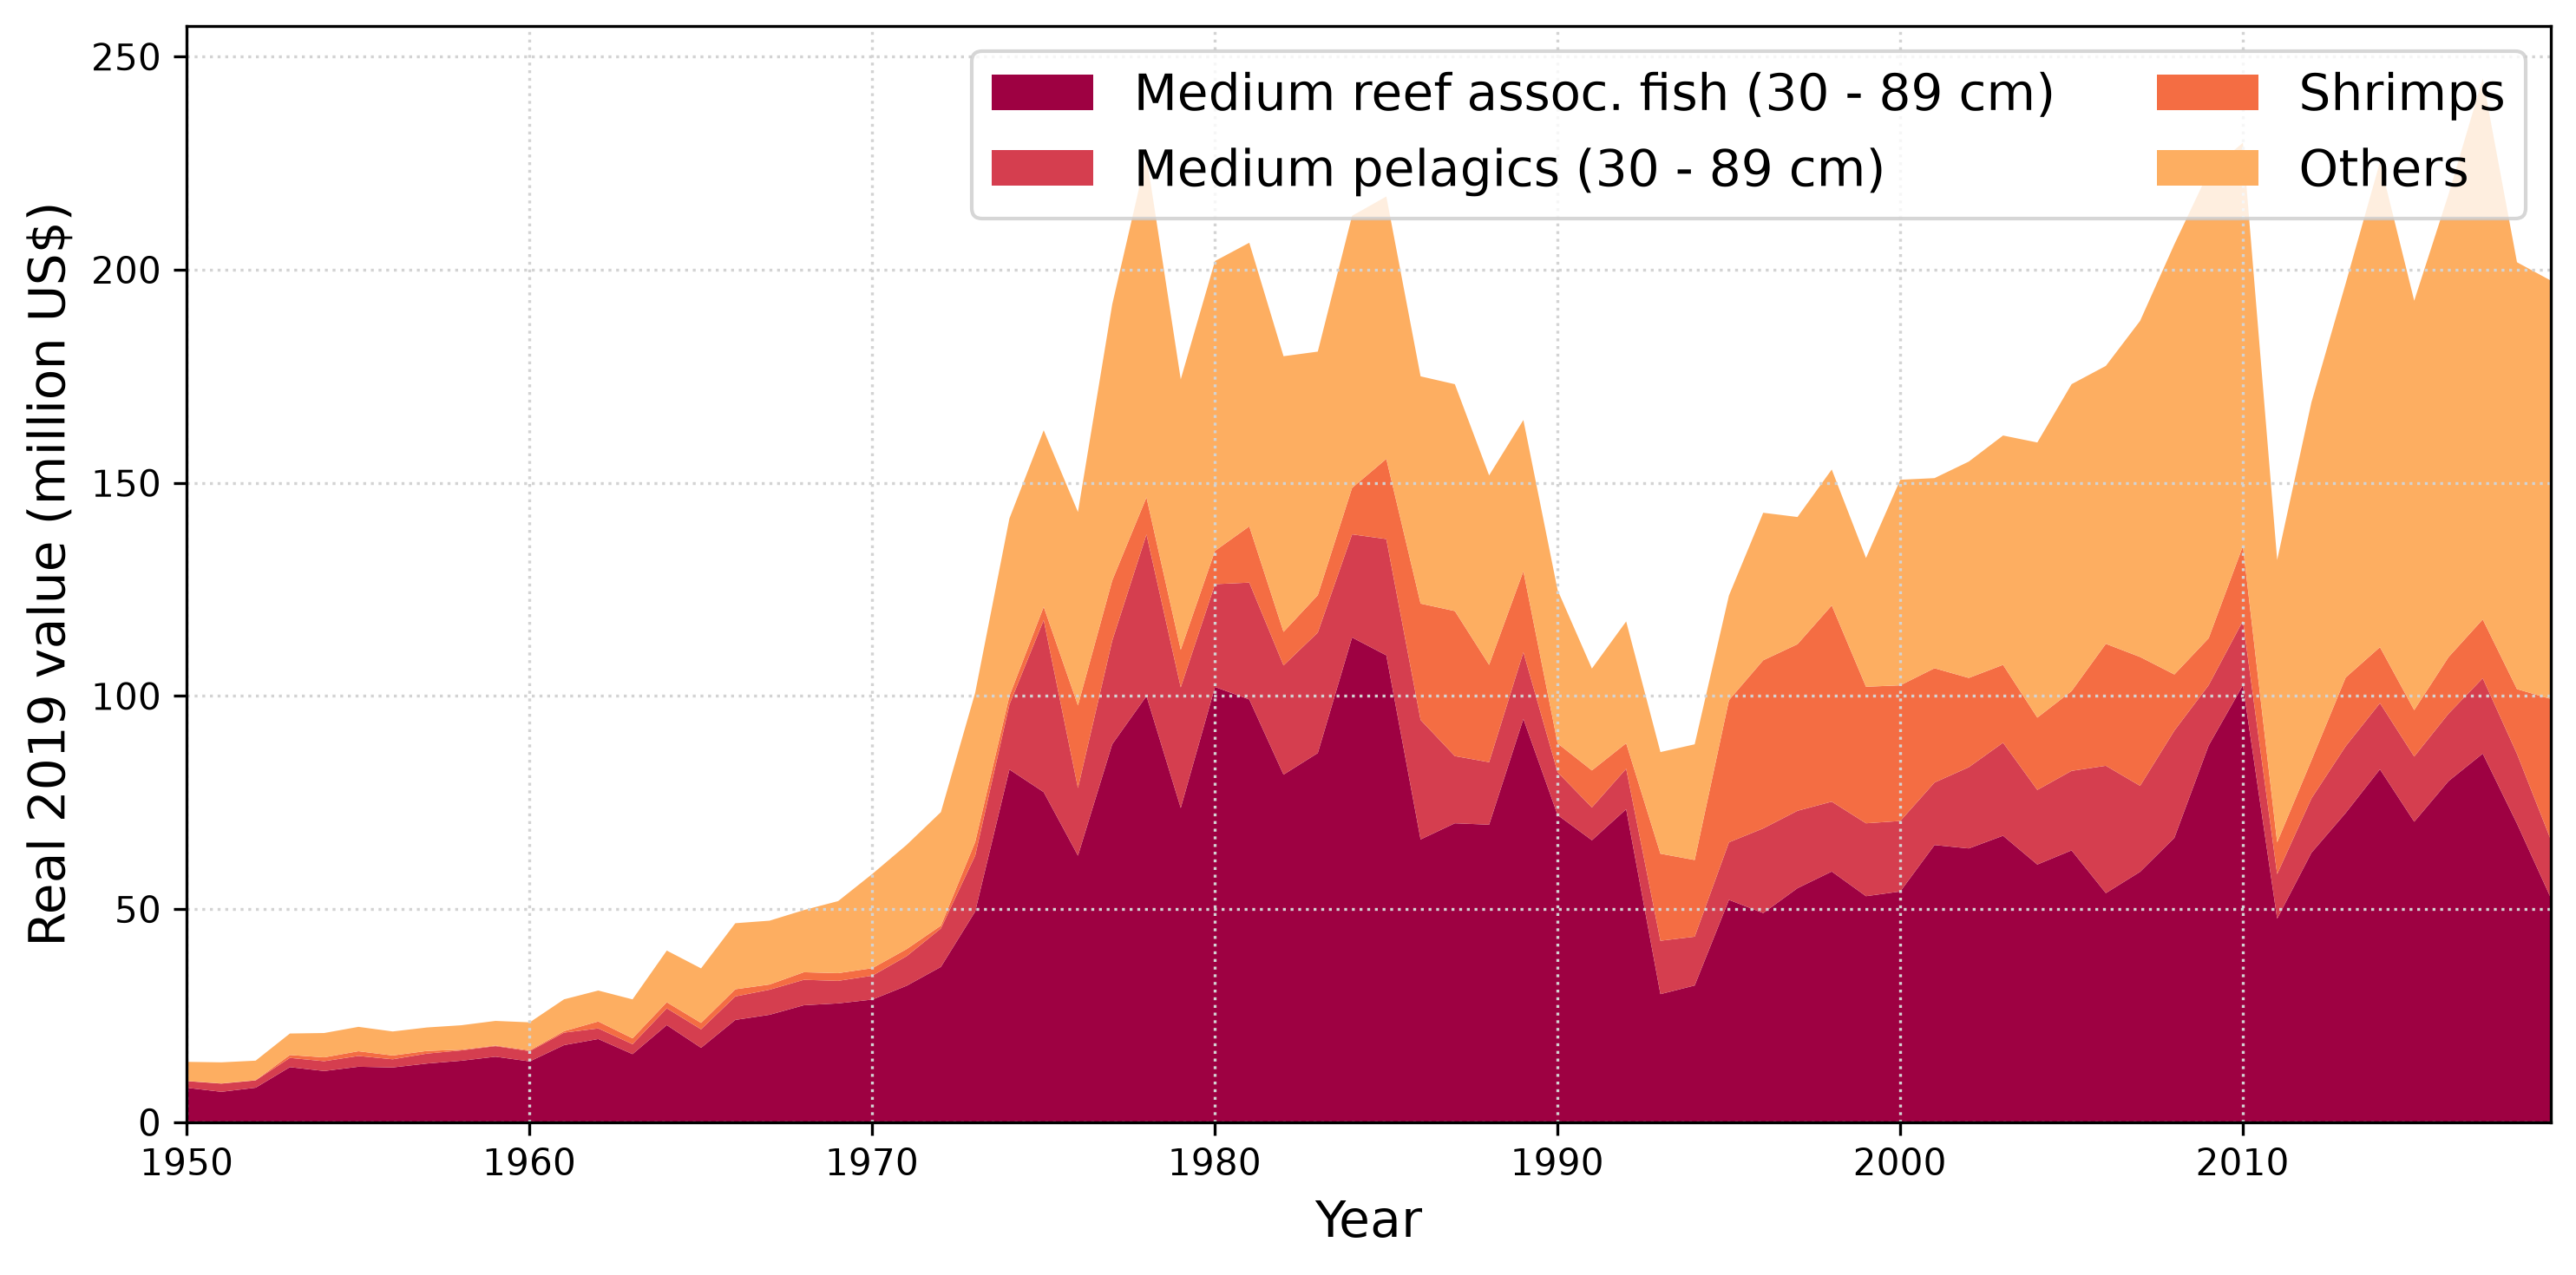

In [21]:
from seaaroundus import plot, config

region = "eez"
region_id = nation_id
dimension = "functionalgroup"
measure = "value"
limit = 3

plt = plot._require_matplotlib()
long_df = catch_data_long(
    region,
    region_id,
    measure=measure,
    dimension=dimension,
    limit=limit,
    client=client,
)
if long_df.empty:
    raise ValueError("No catch data returned for the requested region.")

scale = 1e3 if measure == "tonnage" else 1e6
ylabel = (
    "Catch (1000 x metric tonnage)"
    if measure == "tonnage"
    else "Real 2019 value (million US$)"
)
resolved_name = plot._resolve_region_name(region, region_id, region_name, client=client)
title = f"{resolved_name} ({region.upper()} {region_id}) – {measure} by {config.NAME_ALIASES[dimension]}"

figsize = (10, 5)

fig, ax = plt.subplots(figsize=figsize, dpi=300)

categories = list(dict.fromkeys(long_df["category"]))
colors = plot._category_colors(categories)
bottom = pd.Series(0.0, index=sorted(long_df["year"].unique()))


shade_reef = False
shade_duration = False
start_year = 2009
end_year = 2019
out_of_period_alpha = 0.5  # flat opacity outside the focus window (no extra wash)

# Precompute aligned series so stacked segments stay continuous at the boundaries.
series_by_category = []
for category, color in zip(categories, colors, strict=False):
    subset = long_df[long_df["category"] == category].set_index("year")["value"] / scale
    aligned = subset.reindex(bottom.index, fill_value=0.0)
    series_by_category.append((category, color, aligned))


def _category_alpha(category: str, *, in_period: bool) -> float:
    if shade_duration and not in_period:
        return out_of_period_alpha
    if shade_reef and "reef" not in category.lower():
        return 0.5
    return 1.0


def _draw_stack(
    year_left: int, year_right: int, *, in_period: bool, with_labels: bool
) -> None:
    years = bottom.index[(bottom.index >= year_left) & (bottom.index <= year_right)]
    if len(years) == 0:
        return
    stack = pd.Series(0.0, index=years)
    for category, color, aligned in series_by_category:
        top = stack + aligned.reindex(years, fill_value=0.0)
        ax.fill_between(
            years,
            stack,
            top,
            color=color,
            linewidth=0,
            alpha=_category_alpha(category, in_period=in_period),
            label=category if with_labels else None,
        )
        stack = top


year_min = int(min(long_df.year))
year_max = int(max(long_df.year))

if shade_duration:
    _draw_stack(year_min, start_year, in_period=False, with_labels=False)
    _draw_stack(start_year, end_year, in_period=True, with_labels=True)
    _draw_stack(end_year, year_max, in_period=False, with_labels=False)
else:
    _draw_stack(year_min, year_max, in_period=True, with_labels=True)


ax.set_xlabel("Year", fontsize=14)
ax.set_ylabel(ylabel, fontsize=14)
# ax.set_title(title)
ax.legend(loc="upper right", ncol=2, frameon=True, fontsize=14)
# ax.legend(
#     loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2, frameon=False, fontsize=14
# )
ax.set_xlim(min(long_df.year), max(long_df.year))

# ax.set_xlim(2009,2019)
# plot a point of the average value of the catch by year
# ax.scatter(2015, long_df[(long_df.year >= 2009) & (long_df.year <= 2019)].value.mean()/1e6, label="Average catch")
# set minimum y value to 0
ax.set_ylim(0, ax.get_ylim()[1])
ax.grid("--", c="lightgrey", ls=":")
fig.tight_layout()

Loaded cached EEZ values from eez_catch_value_2019.csv


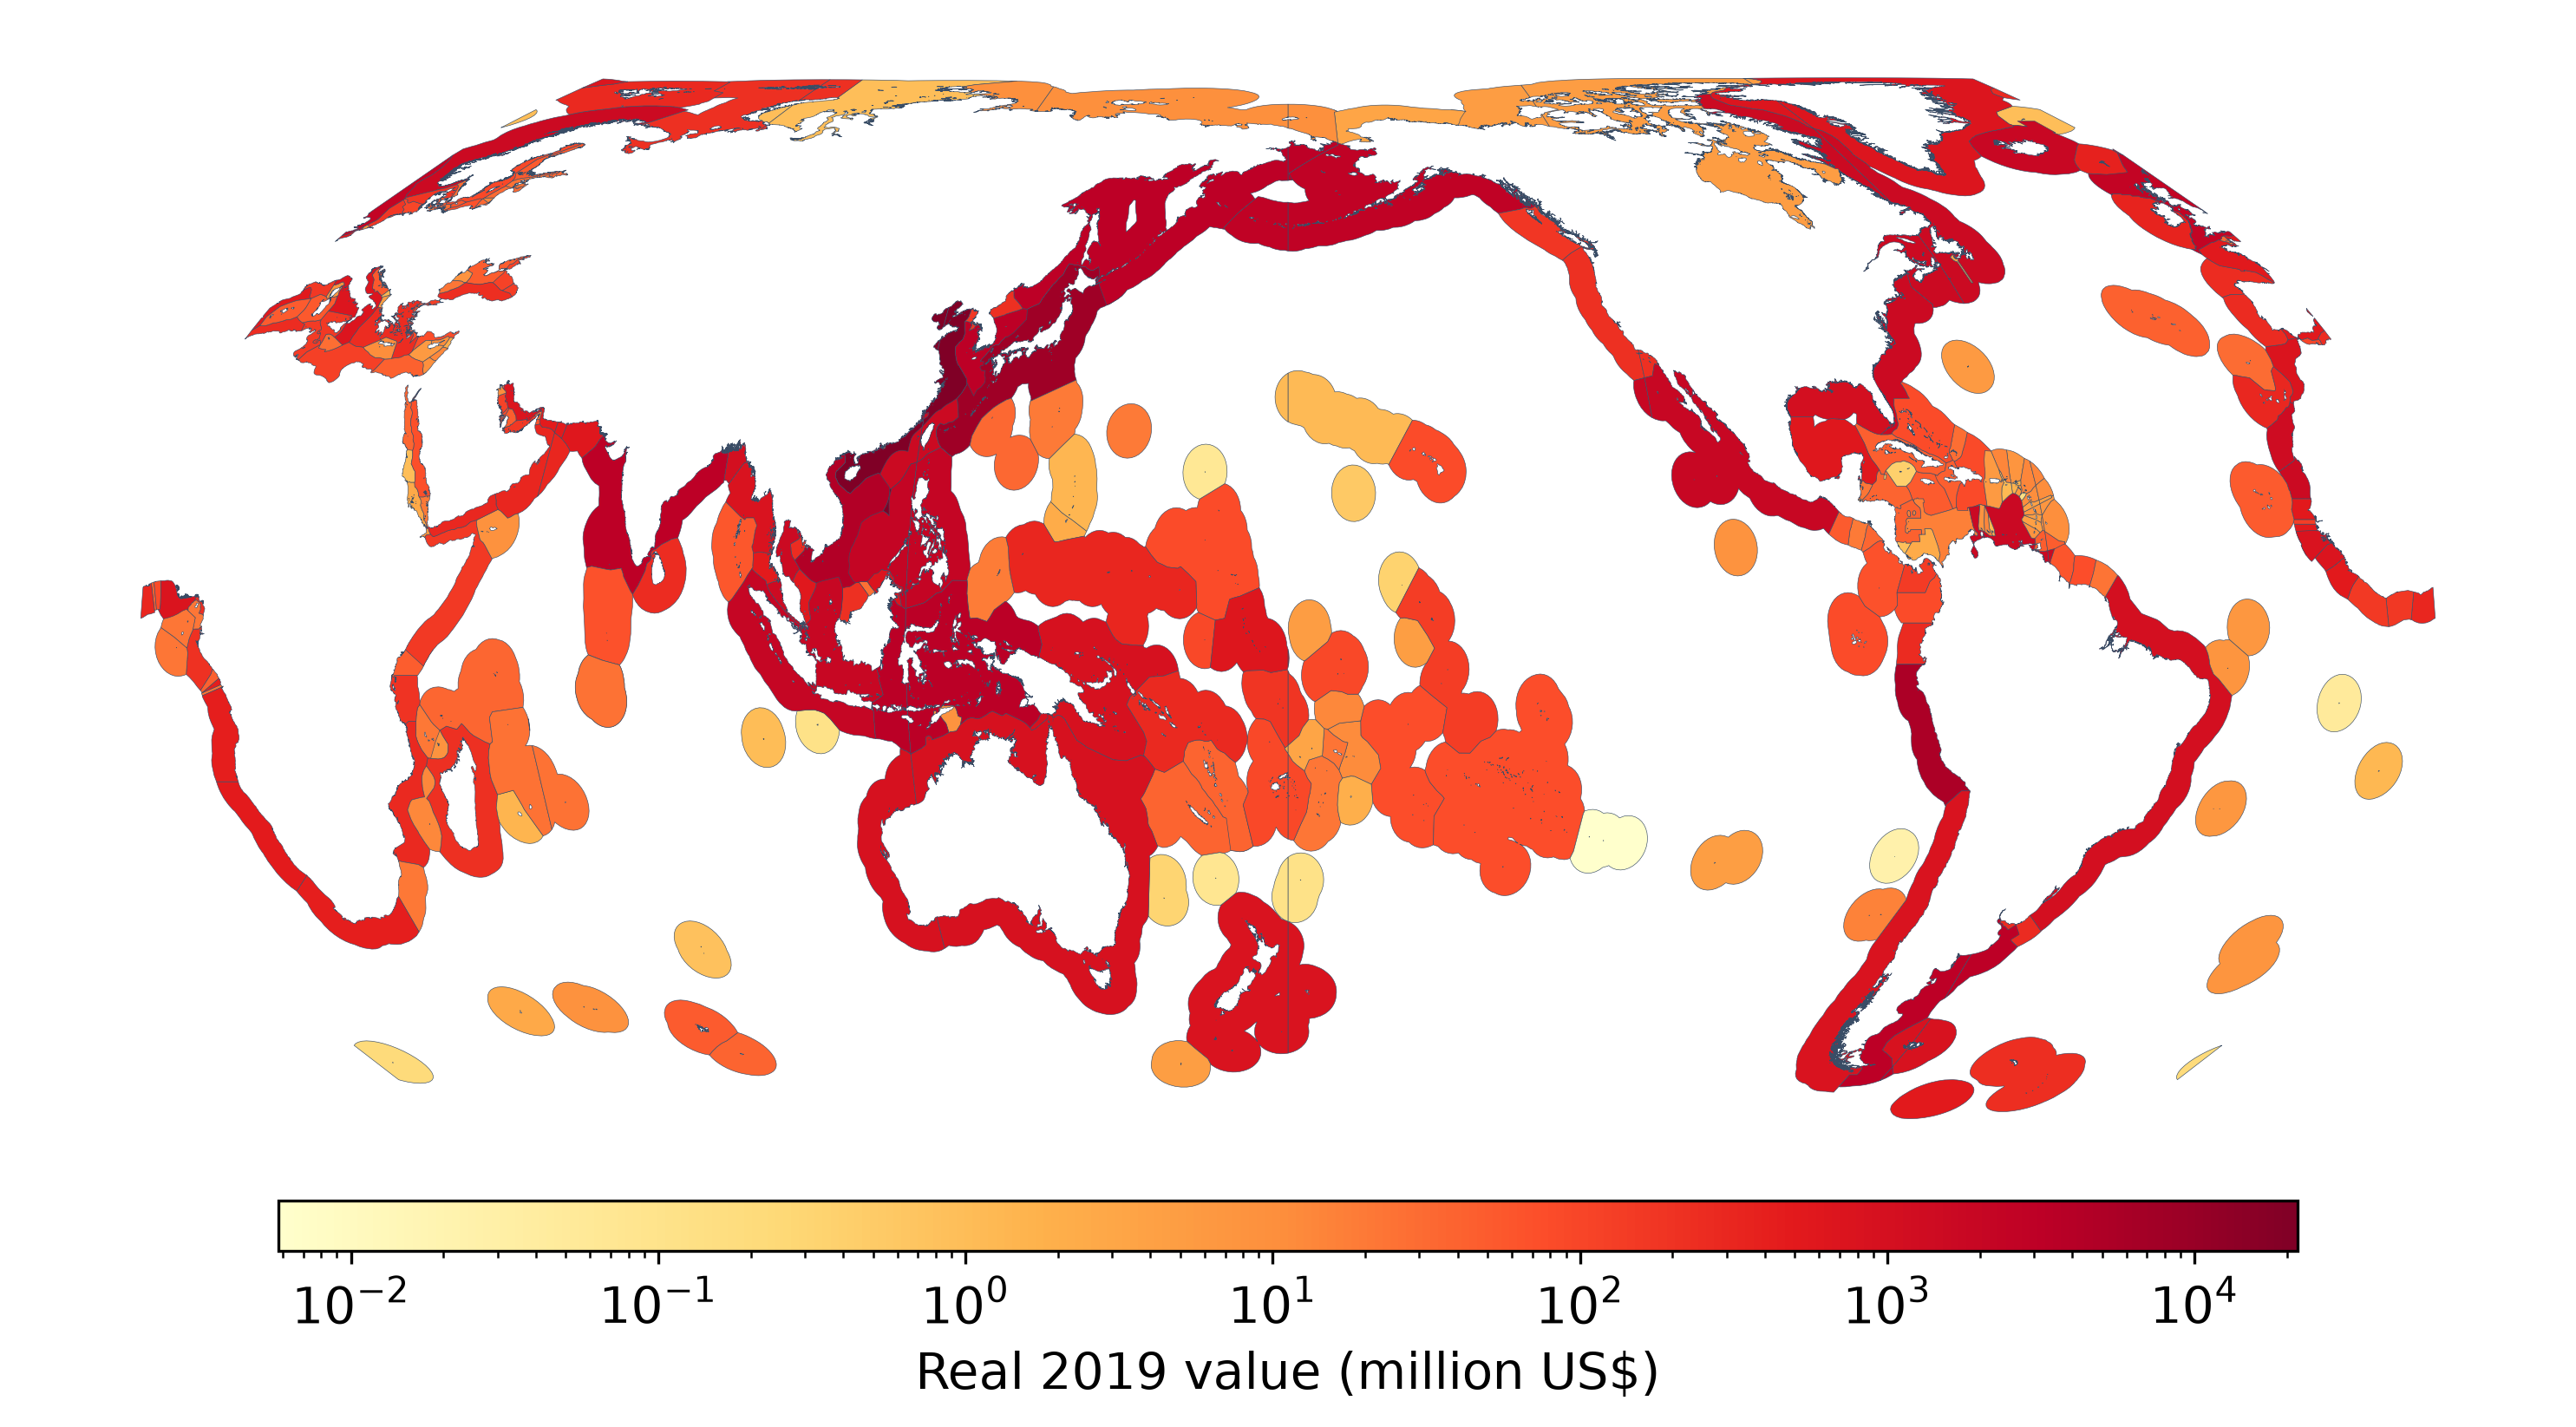

In [22]:
# Global EEZ choropleth: reconstructed catch value in 2019
# Requires optional maps extra: pip install "py-seaaroundus[maps]"
# First run hits the API once per EEZ (~280 calls); later runs use the local CSV + response cache.
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LogNorm
from shapely.geometry import box
from shapely.validation import make_valid

YEAR = 2019
values_path = CACHE_DIR / f"eez_catch_value_{YEAR}.csv"

if values_path.exists():
    values = pd.read_csv(values_path)
    print(f"Loaded cached EEZ values from {values_path.name}")
else:
    eezs = sau.list_regions("eez", client=client)
    records = []
    for n, row in enumerate(eezs.itertuples(index=False), start=1):
        long_df = sau.catch_data_long(
            "eez",
            int(row.id),
            measure="value",
            dimension="sector",  # few series; sum gives total EEZ value
            limit=10,
            client=client,
        )
        total = (
            float(long_df.loc[long_df["year"] == YEAR, "value"].sum())
            if not long_df.empty
            else float("nan")
        )
        records.append({"region_id": int(row.id), "value_2019_usd": total})
        if n % 20 == 0 or n == len(eezs):
            print(f"Fetched catch value for {n}/{len(eezs)} EEZs...")
    values = pd.DataFrame(records)
    values.to_csv(values_path, index=False)
    print(f"Saved {values_path}")

values["value_2019_million"] = values["value_2019_usd"] / 1e6
# LogNorm requires values > 0; keep zeros/negatives as missing.
values.loc[values["value_2019_million"] <= 0, "value_2019_million"] = np.nan

gdf = gpd.GeoDataFrame.from_features(client.fetch_geojson("eez/"), crs="EPSG:4326")
merged = gdf.merge(values, on="region_id", how="left")

# Pacific-centred Equal Earth (lon_0=180). Split geometries into narrow longitude
# panels first so date-line / seam-crossing EEZs do not stretch into horizontal stripes.
_LON_PANELS = [box(lon, -90.0, lon + 60.0 - 1e-9, 90.0) for lon in range(-180, 180, 60)]


def _polygons(geom):
    if geom is None or geom.is_empty:
        return []
    geom = make_valid(geom)
    if geom.geom_type == "Polygon":
        return [geom]
    if geom.geom_type == "MultiPolygon":
        return [part for part in geom.geoms if not part.is_empty]
    if geom.geom_type == "GeometryCollection":
        parts = []
        for geom_part in geom.geoms:
            parts.extend(_polygons(geom_part))
        return parts
    return []


def _split_for_pacific(geom):
    parts = []
    for panel in _LON_PANELS:
        inter = make_valid(geom).intersection(panel)
        for part in _polygons(inter):
            minx, miny, maxx, maxy = part.bounds
            if (maxx - minx) > 1e-6 and (maxy - miny) > 1e-6:
                parts.append(part)
    return parts


plot_rows = []
for row in merged.itertuples(index=False):
    for part in _split_for_pacific(row.geometry):
        plot_rows.append(
            {
                "region_id": row.region_id,
                "value_2019_million": row.value_2019_million,
                "geometry": part,
            }
        )

merged_plot = gpd.GeoDataFrame(plot_rows, crs="EPSG:4326").to_crs(
    "+proj=eqearth +lon_0=180 +datum=WGS84 +units=m +no_defs"
)

positive = merged_plot["value_2019_million"].dropna()
norm = LogNorm(vmin=positive.min(), vmax=positive.max())

fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
merged_plot.plot(
    column="value_2019_million",
    ax=ax,
    cmap="YlOrRd",
    norm=norm,
    edgecolor="#394D66",
    linewidth=0.15,
    legend=True,
    missing_kwds={"color": "#d0d0d0", "edgecolor": "#394D66"},
    legend_kwds={
        "label": "Real 2019 value (million US$)",
        "orientation": "horizontal",
        "shrink": 0.8,
        "aspect": 40,
        "pad": 0.02,
    },
)

# Colorbar lives on a separate axes – size its ticks/label, not ax.tick_params.
cbar_ax = fig.axes[-1]
cbar_ax.tick_params(labelsize=14)
cbar_ax.xaxis.label.set_size(14)

ax.set_facecolor("#81A6D6")
ax.set_axis_off()
# ax.set_title(f"Global EEZ reconstructed catch value ({YEAR})")
fig.tight_layout()
plt.show()


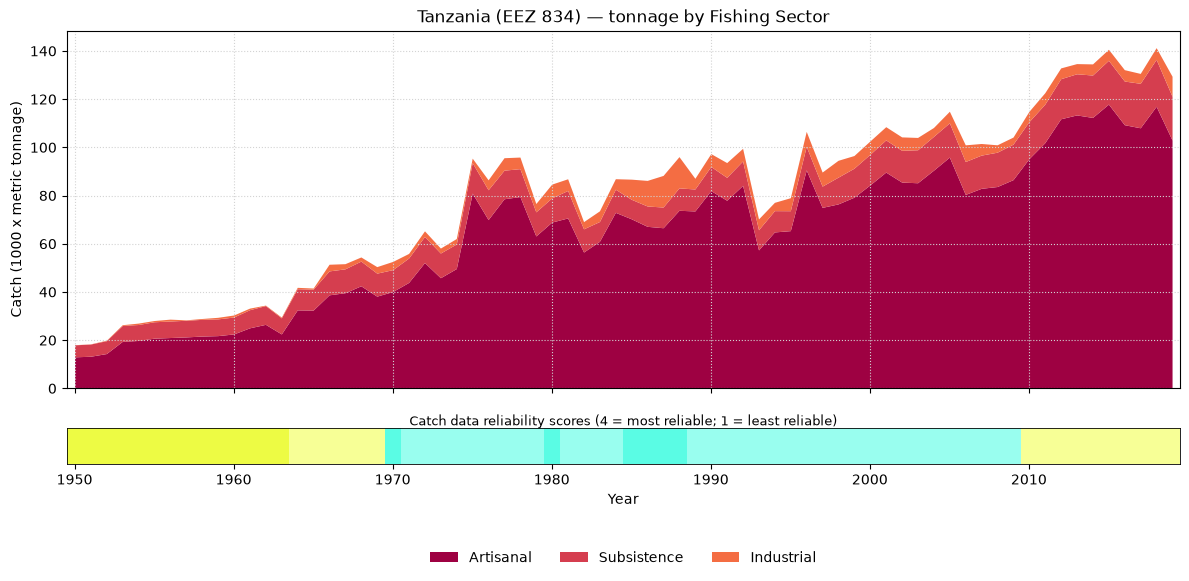

In [23]:
# Sector breakdown (industrial, artisanal, subsistence, etc.)
fig, ax = sau.plot_catch_data(
    "eez",
    nation_id,
    dimension="sector",
    measure="tonnage",
    limit=8,
)

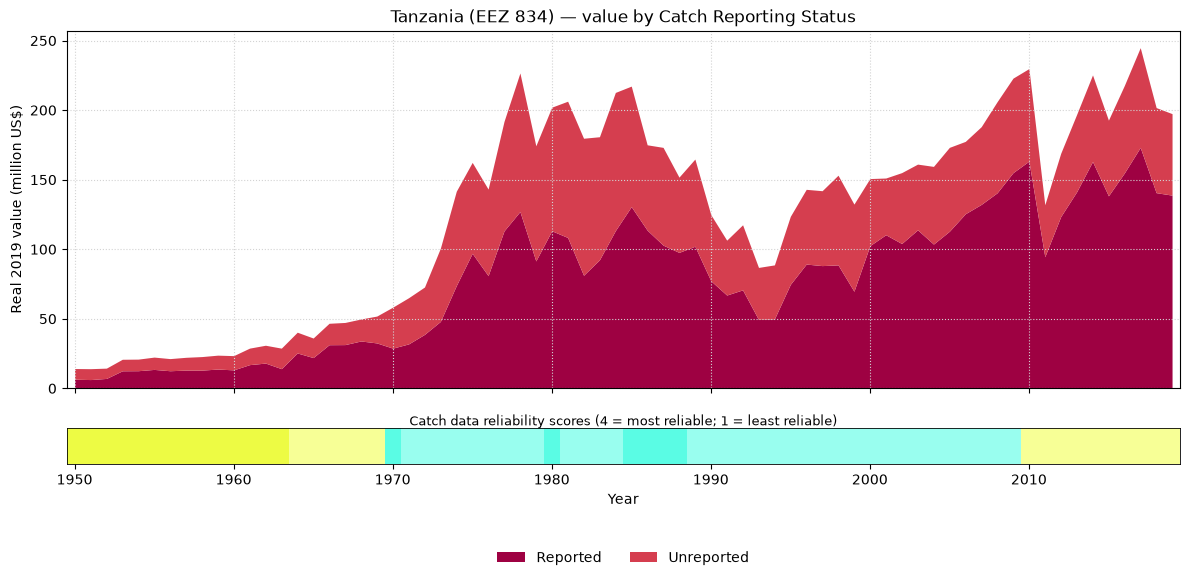

In [24]:
# Reporting-status breakdown by value
fig, ax = sau.plot_catch_data(
    "eez",
    nation_id,
    dimension="reporting-status",
    measure="value",
    limit=6,
)

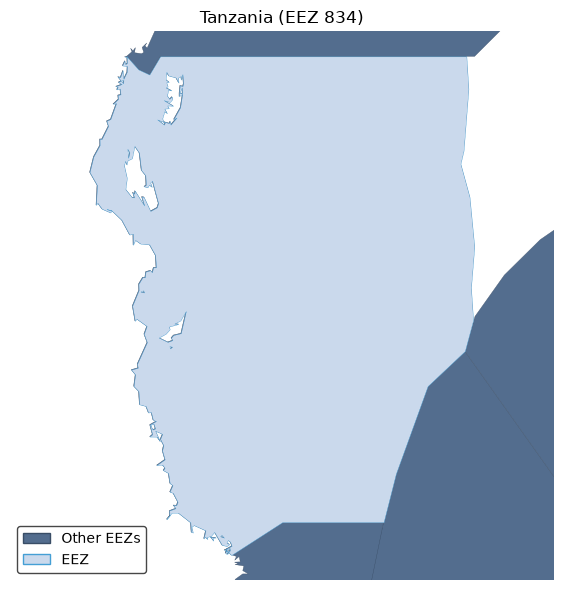

In [25]:
# Plot region map – N.B. requires 'maps' optional dependency
fig, ax = sau.region_map("eez", region_id=nation_id, client=client)

Some queries to the Sea Around Us API are deprecated:

In [26]:
try:
    # Marine trophic index curve
    fig, ax = sau.plot_mti("eez", nation_id, mti_type="mean_trophic_level")
    fig
except Exception as exc:
    print("MTI plotting unavailable:", exc)

/var/folders/tp/x_9dbyf149d6kw_k79l_kk4m0000gq/T/ipykernel_70210/2151793103.py:3: DeprecationWarning: plot_mti is deprecated because marine_trophic_index() relies on an upstream endpoint that currently returns HTTP 500.
  fig, ax = sau.plot_mti("eez", nation_id, mti_type="mean_trophic_level")


MTI plotting unavailable: Sea Around Us API request failed for http://api.seaaroundus.org/api/v1/eez/marine-trophic-index/?region_id=834&transfer_efficiency=0.1


In [27]:
try:
    # Global EEZ vs high-seas area plot
    fig, ax = sau.plot_eez_vs_high_seas()
    fig
except ImportError as exc:
    print("Install plot extras:", exc)
except Exception as exc:
    print("EEZ vs high-seas plotting unavailable:", exc)

EEZ vs high-seas plotting unavailable: 'list' object has no attribute 'get'


/var/folders/tp/x_9dbyf149d6kw_k79l_kk4m0000gq/T/ipykernel_70210/19360529.py:3: DeprecationWarning: plot_eez_vs_high_seas is deprecated because eez_vs_high_seas() relies on an upstream endpoint that is currently unavailable/timing out.
  fig, ax = sau.plot_eez_vs_high_seas()
